In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("Iris.csv")

print("First 10 rows of the dataset:")
print(df.head(10))
print("\nDataset Information:")
df.info()
print("\nSummary Statistics:")
print(df.describe())
df = df.drop("Id", axis=1)


First 10 rows of the dataset:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
5   6            5.4           3.9            1.7           0.4  Iris-setosa
6   7            4.6           3.4            1.4           0.3  Iris-setosa
7   8            5.0           3.4            1.5           0.2  Iris-setosa
8   9            4.4           2.9            1.4           0.2  Iris-setosa
9  10            4.9           3.1            1.5           0.1  Iris-setosa

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns

Visualisation before training


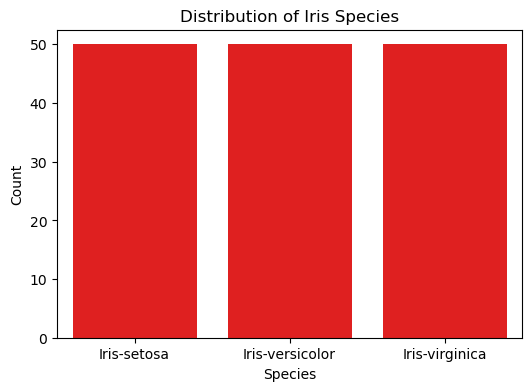

In [16]:

print("Visualisation before training")
plt.figure(figsize=(6,4))
sns.countplot(x="Species", data=df, color = "Red")

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

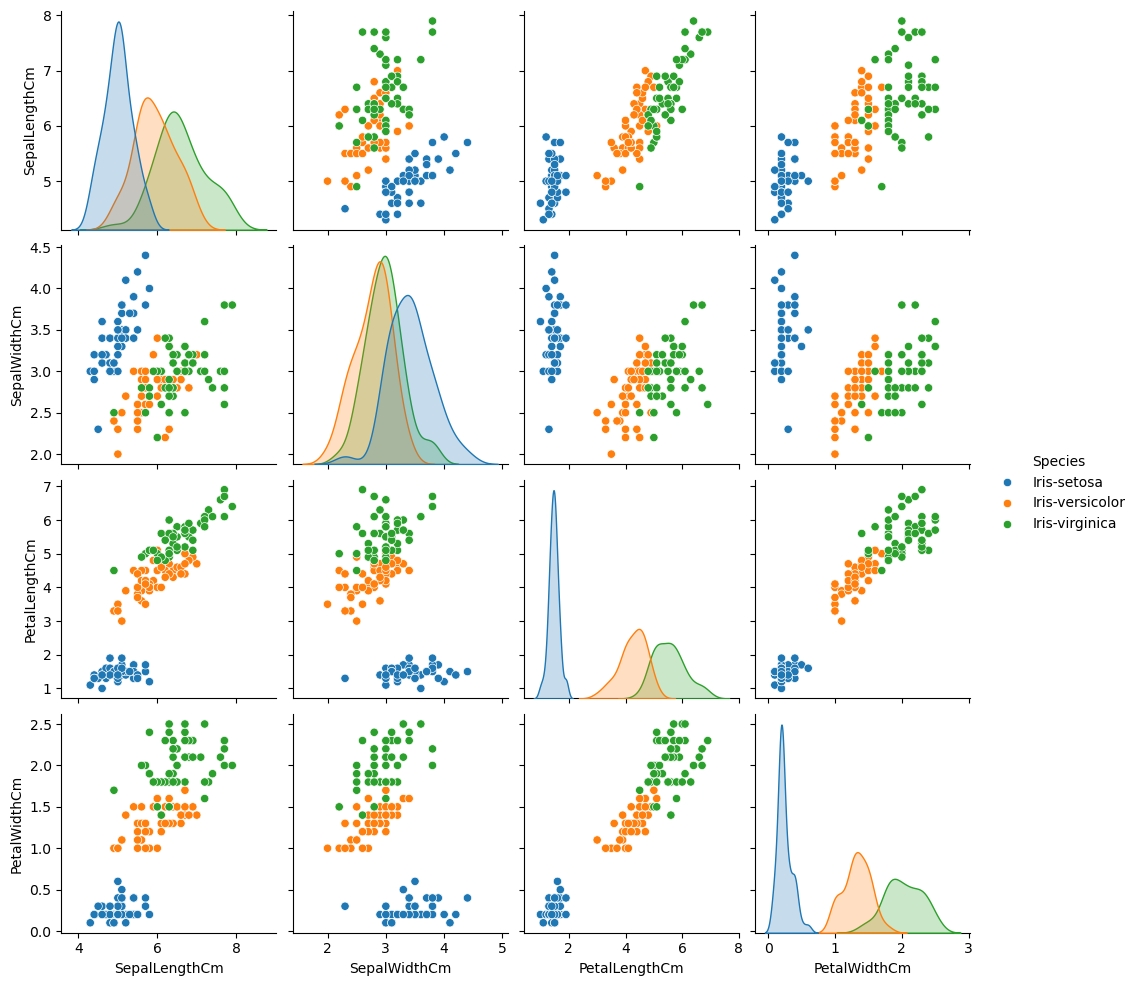

In [19]:
sns.pairplot(df, hue="Species")
plt.show()

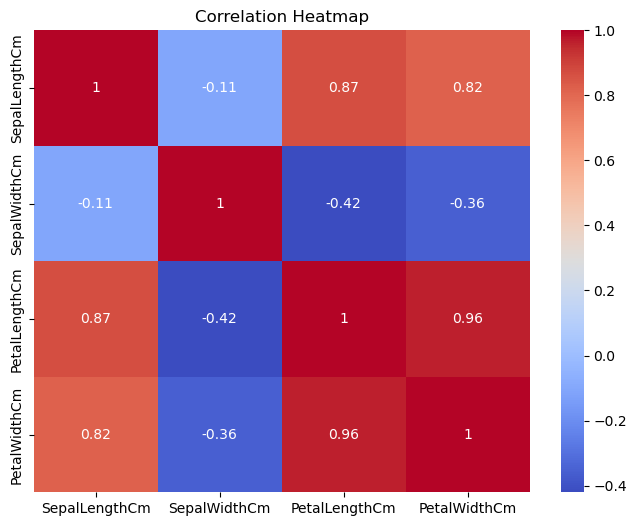

In [20]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop(columns=["Species"]).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

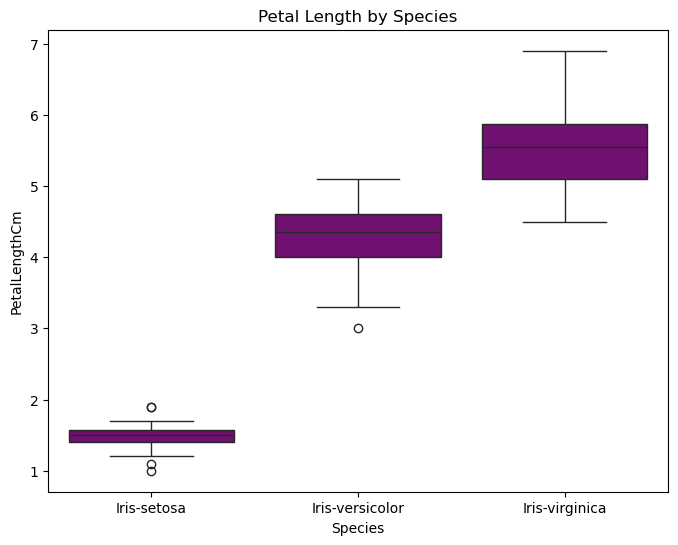

In [22]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="Species",
    y="PetalLengthCm",
    color = "purple",
    data=df
)

plt.title("Petal Length by Species")

plt.show()

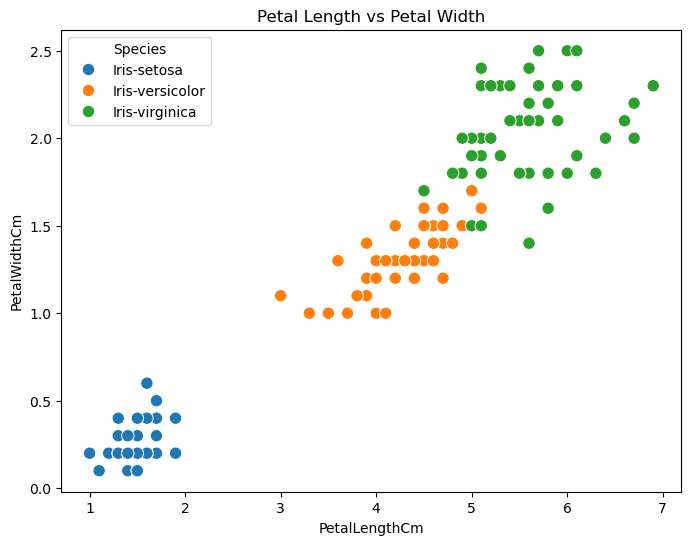

In [23]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="PetalLengthCm",
    y="PetalWidthCm",
    hue="Species",
    data=df,
    s=80
)

plt.title("Petal Length vs Petal Width")

plt.show()

Accuracy: 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


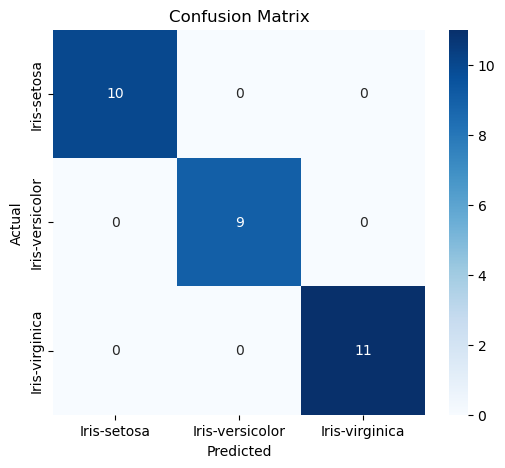


Predicted Species:
['Iris-setosa']


In [25]:

X = df.drop("Species", axis=1)
y = df["Species"]

encoder = LabelEncoder()
y = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Predict a new flower
new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
)

prediction = model.predict(new_flower)

print("\nPredicted Species:")
print(encoder.inverse_transform(prediction))